# Moffitt MERFISH — RF vs LGBM benchmark (v4)

Same pipeline as v3, with two added controls:

- `TOP_K_CLASSES` — keep only the K most abundant classes (or None for all)
- `BALANCE_MODE` — `"weighted"`, `"downsample"`, or `"none"`

Outputs in `/kaggle/working/thesis_outputs/`.


## 1. Control panel


In [18]:
# =============================================================
# CONTROL PANEL — edit these and re-run the whole notebook
# =============================================================

# Data
CSV_PATH      = "/kaggle/input/datasets/mohamedaln/cells-boundaries-clean/cells_boundaries_clean.csv"

# Class granularity
N_CLASSES     = 9           # 15 (raw Cell_class) or 9 (collapsed supertypes)

# Top-K class filter (applied AFTER granularity collapse)
TOP_K_CLASSES = None         # None = keep all; integer = keep top-K by count

# Class balancing
BALANCE_MODE  = "weighted"   # "weighted"   = class_weight="balanced" (default)
                             # "downsample" = per-class downsample to smallest class
                             # "none"       = no balancing

# Models to run
RUN_RF        = True
RUN_LGBM      = True

# Feature engineering
K_NEIGHBORS   = 10           # for neighbor-aggregated features
N_ESTIMATORS  = 300

# Validation
TEST_SIZE     = 0.20
VAL_SIZE      = 0.20         # of the dev set
RUN_LOBO_CV   = True         # leave-Bregma-out CV (slower; set False to skip)
LOBO_FSETS    = ["genes_only", "all_combined"]
N_JOBS        = -1
SEED          = 42

# Plotting
MAX_PLOT      = 20000

# =============================================================
# Imports
# =============================================================
import os, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, accuracy_score,
)
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
np.random.seed(SEED)

# Validate balance mode
assert BALANCE_MODE in ("weighted", "downsample", "none"), \
    f"BALANCE_MODE must be 'weighted', 'downsample', or 'none' — got {BALANCE_MODE!r}"

OUT = Path("/kaggle/working/thesis_outputs")
FIG = OUT / "figures"
TBL = OUT / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TBL.mkdir(parents=True, exist_ok=True)

print("Config:")
print(f"  N_CLASSES={N_CLASSES}  TOP_K_CLASSES={TOP_K_CLASSES}")
print(f"  BALANCE_MODE={BALANCE_MODE!r}")
print(f"  RUN_RF={RUN_RF}  RUN_LGBM={RUN_LGBM}  RUN_LOBO_CV={RUN_LOBO_CV}")
print(f"  K_NEIGHBORS={K_NEIGHBORS}  N_ESTIMATORS={N_ESTIMATORS}  SEED={SEED}")


Config:
  N_CLASSES=9  TOP_K_CLASSES=None
  BALANCE_MODE='weighted'
  RUN_RF=True  RUN_LGBM=True  RUN_LOBO_CV=True
  K_NEIGHBORS=10  N_ESTIMATORS=300  SEED=42


## 2. Load data + apply class granularity, top-K filter, downsample


In [19]:
print("\n[1] Loading...")
df = pd.read_csv(CSV_PATH)
print(f"    shape: {df.shape}")

META = ["Cell_ID","Animal_ID","Animal_sex","Behavior",
        "Bregma","Centroid_X","Centroid_Y",
        "Cell_class","Neuron_cluster_ID","boundaryX","boundaryY"]
GENES = [c for c in df.columns
         if c not in META and "blank" not in c.lower()
         and pd.api.types.is_numeric_dtype(df[c])]

# Drop ambiguous rows
df = df[~df["Cell_class"].astype(str).str.contains("ambiguous", case=False, na=False)]
df = df.dropna(subset=["Cell_class"]).reset_index(drop=True)

# --- Class granularity (15 raw vs 9 collapsed supertypes) ---
def collapse9(label):
    s = str(label)
    if s.startswith("OD Mature"):   return "OD Mature"
    if s.startswith("OD Immature"): return "OD Immature"
    if s.startswith("Endothelial"): return "Endothelial"
    return s

if N_CLASSES == 9:
    df["Cell_class"] = df["Cell_class"].apply(collapse9)
elif N_CLASSES != 15:
    raise ValueError("N_CLASSES must be 9 or 15")

print(f"\n    cells={len(df)}  classes={df['Cell_class'].nunique()}")
print(f"    class counts (sorted desc):")
print(df["Cell_class"].value_counts().to_string())

# --- TOP_K_CLASSES filter ---
if TOP_K_CLASSES is not None:
    if not isinstance(TOP_K_CLASSES, int) or TOP_K_CLASSES < 2:
        raise ValueError("TOP_K_CLASSES must be a positive integer >= 2, or None")
    counts = df["Cell_class"].value_counts()
    if TOP_K_CLASSES > len(counts):
        raise ValueError(
            f"TOP_K_CLASSES={TOP_K_CLASSES} but only {len(counts)} classes exist"
        )
    keep = counts.head(TOP_K_CLASSES).index.tolist()
    print(f"\n    Keeping top {TOP_K_CLASSES} classes: {keep}")
    dropped = counts.tail(len(counts) - TOP_K_CLASSES).index.tolist()
    print(f"    Dropped: {dropped}")
    df = df[df["Cell_class"].isin(keep)].reset_index(drop=True)
    print(f"    cells after filter: {len(df)}")

# --- BALANCE_MODE: downsample option ---
if BALANCE_MODE == "downsample":
    min_n = int(df["Cell_class"].value_counts().min())
    print(f"\n    Downsampling each class to {min_n} cells...")
    df = (df.groupby("Cell_class", group_keys=False)
            .apply(lambda x: x.sample(n=min_n, random_state=SEED))
            .reset_index(drop=True))
    print(f"    cells after downsample: {len(df)}")
    print(df["Cell_class"].value_counts().to_string())

y = df["Cell_class"].values
classes = sorted(np.unique(y))
print(f"\n    final cells={len(df)}  genes={len(GENES)}  classes={len(classes)}")



[1] Loading...
    shape: (35522, 166)

    cells=35522  classes=9
    class counts (sorted desc):
Cell_class
Inhibitory     12429
Excitatory      5997
Astrocyte       5180
OD Mature       4206
Endothelial     3759
OD Immature     1478
Ependymal       1152
Microglia        933
Pericytes        388

    final cells=35522  genes=155  classes=9


## 3. Feature engineering — four families

- **genes**: raw expression (155 genes)
- **shape**: 6 morphological features from boundary polygons
- **spatial**: 3 spatial-context features (per Bregma)
- **neighbors**: K-NN aggregated gene expression (per Bregma)


In [20]:
# -------- 3a. Shape features --------
print("\n[2] Shape features...")

def parse_poly(s):
    if pd.isna(s): return np.array([])
    s = str(s).replace(",", " ").replace(";", " ").strip()
    return np.fromstring(s, sep=" ")

def shape_feats(xs, ys):
    if len(xs) < 3 or len(xs) != len(ys):
        return [np.nan]*6
    area = 0.5*np.abs(np.dot(xs, np.roll(ys,-1)) - np.dot(ys, np.roll(xs,-1)))
    dx = np.diff(np.append(xs, xs[0])); dy = np.diff(np.append(ys, ys[0]))
    perim = np.sum(np.sqrt(dx*dx + dy*dy))
    w = xs.max()-xs.min(); h = ys.max()-ys.min()
    bbox = max(w*h, 1e-9)
    aspect = max(w,h)/max(min(w,h), 1e-9)
    extent = area/bbox
    circ = (4*np.pi*area)/max(perim*perim, 1e-9)
    try:
        from scipy.spatial import ConvexHull
        hull = ConvexHull(np.column_stack([xs, ys]))
        solidity = area/max(hull.volume, 1e-9)
    except Exception:
        solidity = np.nan
    return [area, perim, circ, aspect, solidity, extent]

t0 = time.time()
shape = np.full((len(df), 6), np.nan)
for i, (bx, by) in enumerate(zip(df["boundaryX"].values, df["boundaryY"].values)):
    shape[i] = shape_feats(parse_poly(bx), parse_poly(by))
SHAPE_NAMES = ["m_area","m_perimeter","m_circularity",
               "m_aspect","m_solidity","m_extent"]
shape_df = pd.DataFrame(shape, columns=SHAPE_NAMES, index=df.index)
shape_df = shape_df.fillna(shape_df.median())
print(f"    shape done in {time.time()-t0:.1f}s")



[2] Shape features...
    shape done in 8.2s


In [21]:
# -------- 3b. Spatial features (per Bregma) --------
print("\n[3] Spatial features...")
sp = pd.DataFrame(index=df.index, dtype=float,
                  columns=["dist_to_center","knn_mean_dist","local_density"])
for _, idx in df.groupby("Bregma").groups.items():
    sub = df.loc[idx, ["Centroid_X","Centroid_Y"]].values
    cx, cy = sub[:,0].mean(), sub[:,1].mean()
    sp.loc[idx, "dist_to_center"] = np.sqrt((sub[:,0]-cx)**2 + (sub[:,1]-cy)**2)
    k = min(K_NEIGHBORS+1, len(sub))
    if k > 1:
        nn = NearestNeighbors(n_neighbors=k).fit(sub)
        d, _ = nn.kneighbors(sub)
        sp.loc[idx, "knn_mean_dist"] = d[:,1:].mean(axis=1)
        sp.loc[idx, "local_density"] = 1.0/(d[:,1:].mean(axis=1)+1e-9)
sp = sp.fillna(sp.median())
SPATIAL_NAMES = list(sp.columns)
print(f"    spatial features: {SPATIAL_NAMES}")



[3] Spatial features...
    spatial features: ['dist_to_center', 'knn_mean_dist', 'local_density']


In [22]:
# -------- 3c. Neighbor-aggregated gene features (per Bregma) --------
print("\n[4] Neighbor-aggregated gene features...")
t0 = time.time()
G = df[GENES].astype(float).fillna(0).values
nbr_genes = np.zeros_like(G)

for _, idx in df.groupby("Bregma").groups.items():
    idx_arr = np.array(idx)
    sub = df.loc[idx_arr, ["Centroid_X","Centroid_Y"]].values
    k = min(K_NEIGHBORS+1, len(sub))
    if k <= 1:
        continue
    nn = NearestNeighbors(n_neighbors=k).fit(sub)
    _, kid = nn.kneighbors(sub)              # kid[:,0] is self
    kid = kid[:, 1:]                         # drop self
    g_sub = G[idx_arr]
    nbr_genes[idx_arr] = g_sub[kid].mean(axis=1)

NEIGHBOR_NAMES = [f"nbr_{g}" for g in GENES]
nbr_df = pd.DataFrame(nbr_genes, columns=NEIGHBOR_NAMES, index=df.index)
print(f"    neighbor features done in {time.time()-t0:.1f}s  shape={nbr_df.shape}")



[4] Neighbor-aggregated gene features...
    neighbor features done in 0.3s  shape=(35522, 155)


## 4. Build the ten feature sets


In [23]:
X_genes    = df[GENES].astype(float).fillna(0).values
X_shape    = shape_df.values
X_spatial  = sp.values
X_nbr      = nbr_df.values

FEATURE_SETS = {
    "genes_only":          (X_genes,                                              GENES),
    "shape_only":          (X_shape,                                              SHAPE_NAMES),
    "spatial_only":        (X_spatial,                                            SPATIAL_NAMES),
    "neighbors_only":      (X_nbr,                                                NEIGHBOR_NAMES),
    "genes_shape":         (np.hstack([X_genes, X_shape]),                        GENES + SHAPE_NAMES),
    "genes_spatial":       (np.hstack([X_genes, X_spatial]),                      GENES + SPATIAL_NAMES),
    "genes_neighbors":     (np.hstack([X_genes, X_nbr]),                          GENES + NEIGHBOR_NAMES),
    "spatial_shape":       (np.hstack([X_spatial, X_shape]),                      SPATIAL_NAMES + SHAPE_NAMES),
    "genes_shape_spatial": (np.hstack([X_genes, X_shape, X_spatial]),             GENES + SHAPE_NAMES + SPATIAL_NAMES),
    "all_combined":        (np.hstack([X_genes, X_shape, X_spatial, X_nbr]),      GENES + SHAPE_NAMES + SPATIAL_NAMES + NEIGHBOR_NAMES),
}

print("\n[5] Feature sets:")
for name, (X, fn) in FEATURE_SETS.items():
    print(f"    {name:25s} {X.shape[1]:4d} feats")



[5] Feature sets:
    genes_only                 155 feats
    shape_only                   6 feats
    spatial_only                 3 feats
    neighbors_only             155 feats
    genes_shape                161 feats
    genes_spatial              158 feats
    genes_neighbors            310 feats
    spatial_shape                9 feats
    genes_shape_spatial        164 feats
    all_combined               319 feats


## 5. Train/val/test split (60/20/20, stratified)


In [24]:
print("\n[6] Split...")
idx_all = np.arange(len(df))
idx_dev, idx_test = train_test_split(idx_all, test_size=TEST_SIZE,
                                     stratify=y, random_state=SEED)
idx_train, idx_val = train_test_split(
    idx_dev, test_size=VAL_SIZE/(1-TEST_SIZE),
    stratify=y[idx_dev], random_state=SEED)
print(f"    train/val/test = {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")



[6] Split...
    train/val/test = 21312/7105/7105


## 6. Run RF + LGBM on every feature set


In [25]:
# class_weight is only used in "weighted" mode; in "downsample" or "none" it is None
CLASS_WEIGHT = "balanced" if BALANCE_MODE == "weighted" else None
print(f"\n[7] PRIMARY — RF + LGBM on every feature set  (class_weight={CLASS_WEIGHT})")
print("="*70)

def fit_eval(model_kind, name, X, fnames, save_importance=True, save_cm=True):
    Xtr, Xva, Xte = X[idx_train], X[idx_val], X[idx_test]
    ytr, yva, yte = y[idx_train], y[idx_val], y[idx_test]

    if model_kind == "RF":
        clf = RandomForestClassifier(n_estimators=N_ESTIMATORS, n_jobs=N_JOBS,
                                     random_state=SEED, class_weight=CLASS_WEIGHT)
    elif model_kind == "LGBM":
        clf = LGBMClassifier(objective="multiclass", num_class=len(classes),
                             n_estimators=N_ESTIMATORS, learning_rate=0.05,
                             num_leaves=31, min_child_samples=20,
                             subsample=0.9, colsample_bytree=0.9,
                             class_weight=CLASS_WEIGHT, random_state=SEED,
                             n_jobs=N_JOBS, verbosity=-1)
    else:
        raise ValueError(model_kind)

    t0 = time.time(); clf.fit(Xtr, ytr); fit_t = time.time()-t0
    yp_test = clf.predict(Xte)

    rows = []
    for tag, Xs, ys in [("train",Xtr,ytr),("val",Xva,yva),("test",Xte,yte)]:
        p = clf.predict(Xs) if tag != "test" else yp_test
        rows.append({
            "model":     model_kind,
            "fset":      name,
            "split":     tag,
            "acc":       accuracy_score(ys, p),
            "bal_acc":   balanced_accuracy_score(ys, p),
            "f1_macro":  f1_score(ys, p, average="macro", zero_division=0),
        })

    print(f"  {model_kind:4s} {name:24s} "
          f"test acc={rows[-1]['acc']:.4f} bal={rows[-1]['bal_acc']:.4f} "
          f"f1={rows[-1]['f1_macro']:.4f}  ({fit_t:.1f}s)")

    if save_cm:
        cm = confusion_matrix(yte, yp_test, labels=classes)
        fig, ax = plt.subplots(figsize=(8,7))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"CM — {model_kind} {name}")
        plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(FIG/f"cm_{model_kind}_{name}.png", dpi=180); plt.close()

        rep = classification_report(yte, yp_test, labels=classes,
                                    output_dict=True, zero_division=0)
        pd.DataFrame(rep).T.to_csv(TBL/f"report_{model_kind}_{name}.csv")

    if save_importance and hasattr(clf, "feature_importances_"):
        imp = pd.DataFrame({"feature": fnames,
                            "importance": clf.feature_importances_}
                          ).sort_values("importance", ascending=False)
        imp.to_csv(TBL/f"importance_{model_kind}_{name}.csv", index=False)

    return rows

all_rows = []
for fset_name, (X, fnames) in FEATURE_SETS.items():
    if RUN_RF:
        all_rows.extend(fit_eval("RF",   fset_name, X, fnames))
    if RUN_LGBM:
        all_rows.extend(fit_eval("LGBM", fset_name, X, fnames))

summary = pd.DataFrame(all_rows)
summary.to_csv(TBL/"benchmark_summary.csv", index=False)
print("\n=== TEST SUMMARY ===")
test_only = summary[summary["split"]=="test"].sort_values(
    ["model","f1_macro"], ascending=[True, False])
print(test_only.to_string(index=False))



[7] PRIMARY — RF + LGBM on every feature set  (class_weight=balanced)
  RF   genes_only               test acc=0.9457 bal=0.9276 f1=0.9400  (25.4s)
  LGBM genes_only               test acc=0.9551 bal=0.9441 f1=0.9495  (27.8s)
  RF   shape_only               test acc=0.3198 bal=0.1402 f1=0.1298  (9.9s)
  LGBM shape_only               test acc=0.2166 bal=0.1721 f1=0.1555  (3.4s)
  RF   spatial_only             test acc=0.2680 bal=0.1630 f1=0.1669  (7.3s)
  LGBM spatial_only             test acc=0.1692 bal=0.2055 f1=0.1524  (2.9s)
  RF   neighbors_only           test acc=0.4942 bal=0.3612 f1=0.3512  (53.2s)
  LGBM neighbors_only           test acc=0.4522 bal=0.3825 f1=0.3741  (28.9s)
  RF   genes_shape              test acc=0.9419 bal=0.9230 f1=0.9369  (27.1s)
  LGBM genes_shape              test acc=0.9544 bal=0.9425 f1=0.9481  (29.5s)
  RF   genes_spatial            test acc=0.9445 bal=0.9230 f1=0.9380  (26.2s)
  LGBM genes_spatial            test acc=0.9545 bal=0.9440 f1=0.9489  (27.9

## 7. Comparison bar chart


In [26]:
test_only = summary[summary["split"]=="test"].copy()
piv = test_only.pivot(index="fset", columns="model", values="f1_macro")
piv = piv.sort_values(piv.columns[0], ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, 0.45*len(piv))))
piv.plot(kind="barh", ax=ax, width=0.75)
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", padding=2, fontsize=8)
ax.set_xlabel("Test macro-F1")
title = f"RF vs LGBM — {N_CLASSES}-class"
if TOP_K_CLASSES is not None:
    title += f" — top-{TOP_K_CLASSES}"
title += f" — balance={BALANCE_MODE}"
ax.set_title(title)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG/"benchmark_comparison.png", dpi=200); plt.close()
print("Saved figures/benchmark_comparison.png")


Saved figures/benchmark_comparison.png


## 8. Per-class F1


In [27]:
rows = []
for m in (["RF"] if RUN_RF else []) + (["LGBM"] if RUN_LGBM else []):
    for fset in ["genes_only", "all_combined"]:
        path = TBL/f"report_{m}_{fset}.csv"
        if not path.exists(): continue
        rep = pd.read_csv(path, index_col=0)
        for cls in classes:
            if cls in rep.index:
                rows.append({"model":m, "fset":fset, "class":cls,
                             "f1": rep.loc[cls,"f1-score"],
                             "support": rep.loc[cls,"support"]})
per_class = pd.DataFrame(rows)
per_class.to_csv(TBL/"per_class_f1.csv", index=False)

counts = df["Cell_class"].value_counts().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.4*len(classes))))
axes[0].barh(counts.index, counts.values, color="steelblue")
axes[0].set_xlabel("Cell count"); axes[0].set_title("Class support (current dataset)")

if RUN_RF:
    sub = per_class[(per_class["model"]=="RF") & (per_class["fset"]=="genes_only")]
    sub = sub.set_index("class").reindex(counts.index)
    axes[1].barh(sub.index, sub["f1"], color="seagreen")
    axes[1].set_xlim(0, 1.0)
    axes[1].set_xlabel("Per-class F1"); axes[1].set_title("RF genes_only — per-class F1")
plt.tight_layout(); plt.savefig(FIG/"per_class_support_vs_f1.png", dpi=200); plt.close()

if RUN_RF:
    print("\n=== Per-class F1 (RF genes_only) ===")
    print(sub[["support","f1"]].to_string())
    zero = sub[sub["f1"]==0]
    if len(zero):
        print(f"\nClasses with F1=0: {list(zero.index)}")
        print("→ Likely caused by very low support; the classifier never sees enough examples.")



=== Per-class F1 (RF genes_only) ===
             support        f1
Cell_class                    
Pericytes       78.0  0.841379
Microglia      187.0  0.942466
Ependymal      230.0  0.960526
OD Immature    296.0  0.965278
Endothelial    752.0  0.960693
OD Mature      841.0  0.986399
Astrocyte     1036.0  0.969319
Excitatory    1199.0  0.891823
Inhibitory    2486.0  0.942483


## 9. Shape feature importance


In [28]:
if RUN_RF and (TBL/"importance_RF_shape_only.csv").exists():
    imp_shape = pd.read_csv(TBL/"importance_RF_shape_only.csv")
    print("Shape feature importance (RF, shape_only):")
    print(imp_shape.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7,4))
    ax.barh(imp_shape["feature"][::-1], imp_shape["importance"][::-1], color="darkorange")
    ax.set_xlabel("Gini importance")
    ax.set_title("Shape feature importance (RF, shape_only)")
    plt.tight_layout(); plt.savefig(FIG/"shape_importance.png", dpi=200); plt.close()

    sf = summary[(summary["fset"]=="shape_only") & (summary["split"]=="test")]
    print("\nShape-only test F1:")
    print(sf[["model","f1_macro","bal_acc","acc"]].to_string(index=False))


Shape feature importance (RF, shape_only):
      feature  importance
m_circularity    0.172844
     m_extent    0.171668
   m_solidity    0.167194
  m_perimeter    0.163736
       m_area    0.163125
     m_aspect    0.161434

Shape-only test F1:
model  f1_macro  bal_acc      acc
   RF  0.129826 0.140229 0.319775
 LGBM  0.155486 0.172056 0.216608


## 10. Leave-Bregma-out CV


In [29]:
if RUN_LOBO_CV:
    print("\n[8] LEAVE-BREGMA-OUT CV")
    print("="*70)
    groups = df["Bregma"].values
    n_splits = min(5, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)

    cv_rows = []
    for fset_name in LOBO_FSETS:
        X_fs, _ = FEATURE_SETS[fset_name]
        print(f"\n  [{fset_name}]  ({X_fs.shape[1]} feats)")
        for fold, (tr, te) in enumerate(gkf.split(X_fs, y, groups=groups), 1):
            for mk in (["RF"] if RUN_RF else []) + (["LGBM"] if RUN_LGBM else []):
                if mk == "RF":
                    m = RandomForestClassifier(n_estimators=N_ESTIMATORS, n_jobs=N_JOBS,
                                               random_state=SEED, class_weight=CLASS_WEIGHT)
                else:
                    m = LGBMClassifier(objective="multiclass", num_class=len(classes),
                                       n_estimators=N_ESTIMATORS, learning_rate=0.05,
                                       num_leaves=31, min_child_samples=20,
                                       subsample=0.9, colsample_bytree=0.9,
                                       class_weight=CLASS_WEIGHT, random_state=SEED,
                                       n_jobs=N_JOBS, verbosity=-1)
                m.fit(X_fs[tr], y[tr])
                yp = m.predict(X_fs[te])
                f1m = f1_score(y[te], yp, average="macro", zero_division=0)
                bal = balanced_accuracy_score(y[te], yp)
                acc = accuracy_score(y[te], yp)
                held = sorted(np.unique(groups[te]))
                print(f"    {mk:4s} fold {fold}: held={held}  f1={f1m:.4f} bal={bal:.4f}")
                cv_rows.append({"model":mk, "fset":fset_name, "fold":fold,
                                "f1_macro":f1m, "bal_acc":bal, "acc":acc})

    cv_df = pd.DataFrame(cv_rows)
    cv_df.to_csv(TBL/"lobo_cv_folds.csv", index=False)
    cv_summary = cv_df.groupby(["model","fset"]).agg(
        f1_macro_mean=("f1_macro","mean"), f1_macro_std=("f1_macro","std"),
        bal_acc_mean=("bal_acc","mean"), acc_mean=("acc","mean"),
    ).reset_index()
    cv_summary.to_csv(TBL/"lobo_cv_summary.csv", index=False)
    print("\n=== LOBO CV SUMMARY ===")
    print(cv_summary.to_string(index=False))
else:
    print("LOBO CV skipped (RUN_LOBO_CV=False)")



[8] LEAVE-BREGMA-OUT CV

  [genes_only]  (155 feats)
    RF   fold 1: held=[np.float64(-0.29), np.float64(-0.09)]  f1=0.9403 bal=0.9263
    LGBM fold 1: held=[np.float64(-0.29), np.float64(-0.09)]  f1=0.9569 bal=0.9534
    RF   fold 2: held=[np.float64(-0.24), np.float64(0.16)]  f1=0.9515 bal=0.9385
    LGBM fold 2: held=[np.float64(-0.24), np.float64(0.16)]  f1=0.9597 bal=0.9527
    RF   fold 3: held=[np.float64(0.01), np.float64(0.06), np.float64(0.26)]  f1=0.9278 bal=0.9106
    LGBM fold 3: held=[np.float64(0.01), np.float64(0.06), np.float64(0.26)]  f1=0.9408 bal=0.9341
    RF   fold 4: held=[np.float64(-0.14), np.float64(-0.04), np.float64(0.21)]  f1=0.9177 bal=0.8938
    LGBM fold 4: held=[np.float64(-0.14), np.float64(-0.04), np.float64(0.21)]  f1=0.9439 bal=0.9323
    RF   fold 5: held=[np.float64(-0.19), np.float64(0.11)]  f1=0.9504 bal=0.9352
    LGBM fold 5: held=[np.float64(-0.19), np.float64(0.11)]  f1=0.9563 bal=0.9472

  [all_combined]  (319 feats)
    RF   fold 1: held

## 11. Inventory + config dump


DONE

--- TABLES ---

[benchmark_summary.csv]
model         fset split      acc  bal_acc  f1_macro
   RF   genes_only train 1.000000 1.000000  1.000000
   RF   genes_only   val 0.942857 0.919383  0.938128
   RF   genes_only  test 0.945672 0.927611  0.940041
 LGBM   genes_only train 1.000000 1.000000  1.000000
 LGBM   genes_only   val 0.951443 0.932966  0.942996
 LGBM   genes_only  test 0.955102 0.944148  0.949485
   RF   shape_only train 0.998686 0.998875  0.993139
   RF   shape_only   val 0.328501 0.143553  0.131614
   RF   shape_only  test 0.319775 0.140229  0.129826
 LGBM   shape_only train 0.595674 0.767021  0.610021
 LGBM   shape_only   val 0.227023 0.176261  0.162598
 LGBM   shape_only  test 0.216608 0.172056  0.155486
   RF spatial_only train 1.000000 1.000000  1.000000
   RF spatial_only   val 0.269529 0.156183  0.159620
   RF spatial_only  test 0.267980 0.163045  0.166862
... (60 total rows)

[lobo_cv_folds.csv]
model         fset  fold  f1_macro  bal_acc      acc
   RF   gene

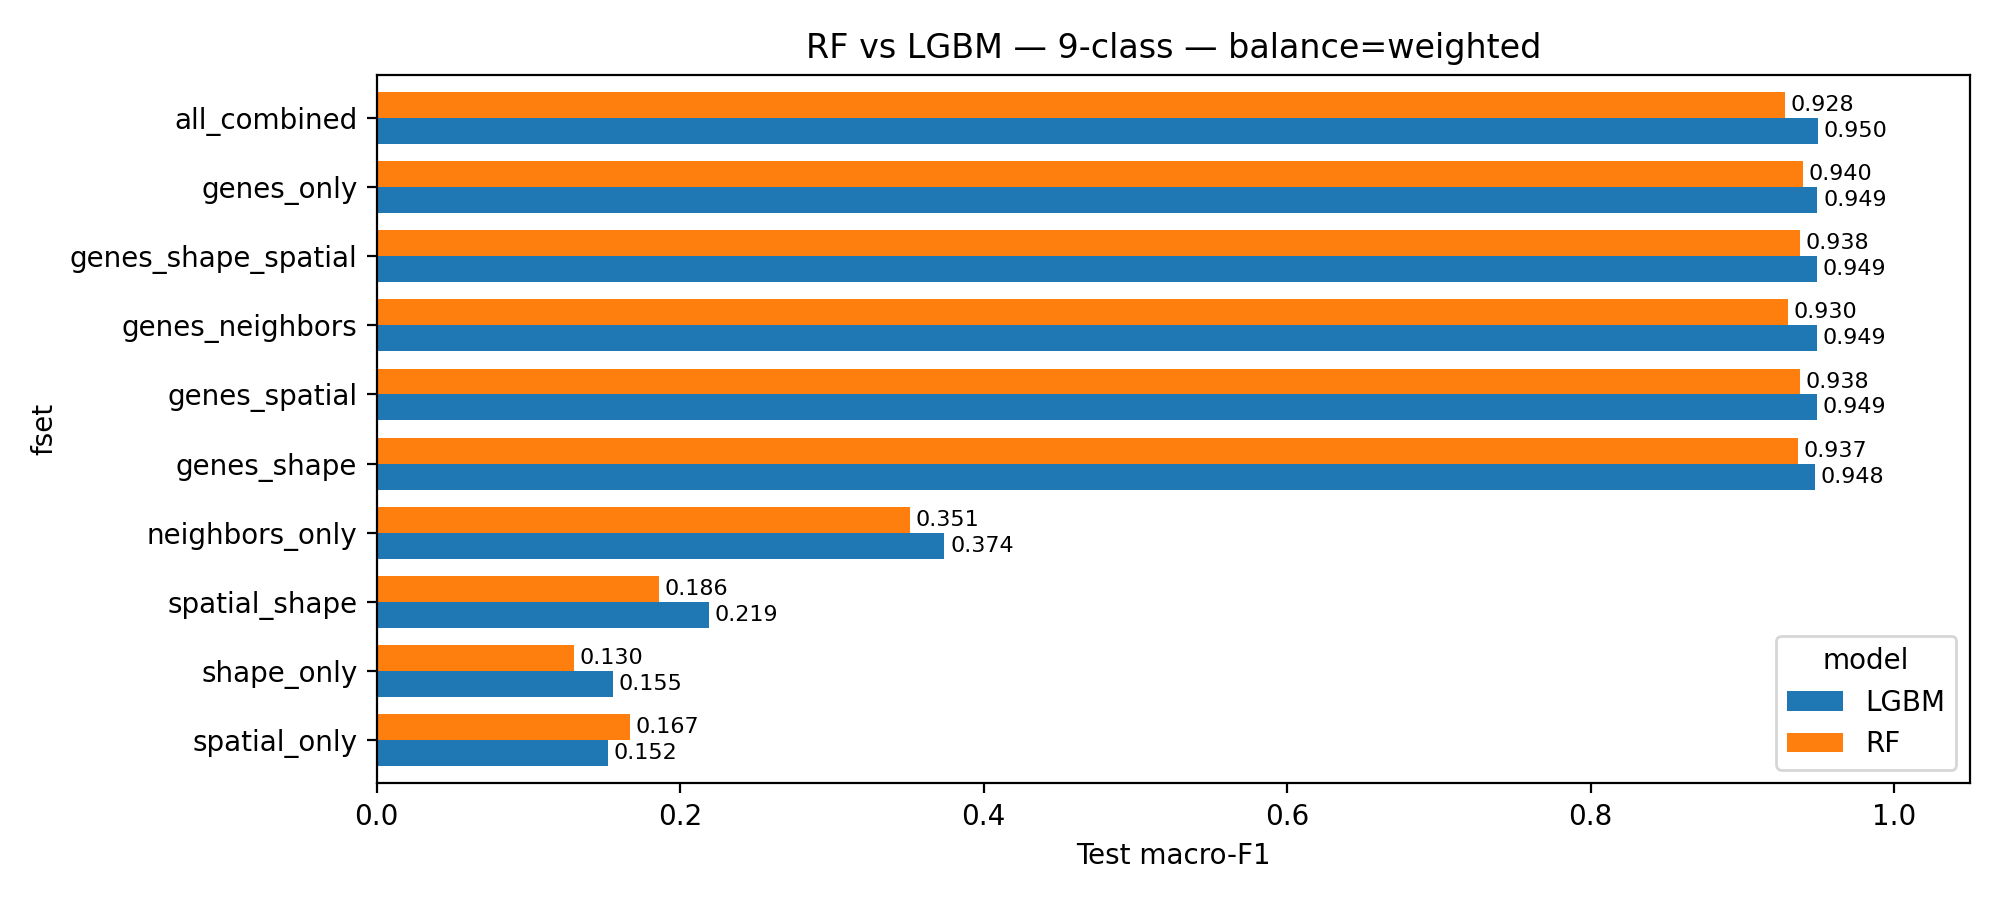

In [30]:
with open(TBL/"config_v4.json","w") as f:
    json.dump({
        "csv": CSV_PATH, "seed": SEED,
        "n_classes": N_CLASSES,
        "top_k_classes": TOP_K_CLASSES,
        "balance_mode": BALANCE_MODE,
        "run_rf": RUN_RF, "run_lgbm": RUN_LGBM,
        "k_neighbors": K_NEIGHBORS, "n_estimators": N_ESTIMATORS,
        "n_cells": int(len(df)), "n_genes": len(GENES),
        "classes": [str(c) for c in classes],
        "feature_sets": list(FEATURE_SETS.keys()),
        "run_lobo_cv": RUN_LOBO_CV,
        "lobo_fsets": LOBO_FSETS,
    }, f, indent=2)

# Cleanup: keep only useful files
KEEP_TABLES = {"benchmark_summary.csv", "lobo_cv_folds.csv",
               "lobo_cv_summary.csv", "per_class_f1.csv", "config_v4.json"}
KEEP_FIGURES = {"benchmark_comparison.png"}

for fn in os.listdir(TBL):
    if fn in KEEP_TABLES or (fn.startswith("report_") and fn.endswith(".csv")):
        continue
    os.remove(TBL/fn)

for fn in os.listdir(FIG):
    if fn not in KEEP_FIGURES:
        os.remove(FIG/fn)

# Review remaining files
from IPython.display import Image, display
import pandas as pd

print("="*60)
print("DONE")
print("="*60)

print("\n--- TABLES ---")
for f in sorted(TBL.glob("*.csv")):
    print(f"\n[{f.name}]")
    df_t = pd.read_csv(f)
    if len(df_t) > 30:
        print(df_t.head(15).to_string(index=False))
        print(f"... ({len(df_t)} total rows)")
    else:
        print(df_t.to_string(index=False))

print("\n--- FIGURES ---")
for f in sorted(FIG.glob("*.png")):
    print(f"\n[{f.name}]")
    display(Image(str(f)))